# Skill Memory vs. OCL Survey strategies

This notebook compares the native **Skill Memory** strategy with the OCL Survey strategies using the same result format and post-processing utilities.

Reference results can be inspected directly from `results/`. To reproduce results from a fresh checkout/Colab, run the experiment commands separately and then rerun this notebook.


In [1]:
from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent
elif not (REPO_ROOT / "src").is_dir():
    for parent in [REPO_ROOT, *REPO_ROOT.parents]:
        if (parent / "src").is_dir() and (parent / "src" / "toolkit").is_dir():
            REPO_ROOT = parent
            break

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.toolkit.process_results import extract_results
from src.toolkit.post_metrics import (
    compute_average_forgetting,
    compute_AAA,
    compute_wcacc,
)

RESULTS_ROOT = REPO_ROOT / "results"
BENCHMARK, NUM_TASKS, MEMORY_SIZE = "split_cifar100", 20, 2000

STRATEGIES = {
    "Skill Memory": "skill_memory",
    "ER": "er",
    "ER-ACE": "er_ace",
    "DER++": "der",
    "MIR": "mir",
    "ER + LwF": "er_lwf",
    "RAR": "rar",
    "SCR": "scr",
    "AGEM": "agem",
    "MER": "mer",
    "iCaRL": "icarl",
    "GDumb": "gdumb",
}

TEST_STREAM = "Top1_Acc_Stream/eval_phase/test_stream/Task000"
VALID_STREAM = "Top1_Acc_Stream/eval_phase/valid_stream/Task000"
TEST_EXP = "Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp"
VALID_EXP = "Top1_Acc_Exp/eval_phase/valid_stream/Task000/Exp"

sns.set_theme(style="whitegrid", context="notebook")


## 1. Load OCL Survey results

Results are discovered using `<strategy>_<benchmark>_<tasks>_<memory>`. Missing methods are reported rather than treated as zero.

In [2]:
def result_name(prefix):
    return f"{prefix}_{BENCHMARK}_{NUM_TASKS}_{MEMORY_SIZE}"

result_dirs = {label: result_name(prefix) for label, prefix in STRATEGIES.items()}
available = {label: RESULTS_ROOT / name for label, name in result_dirs.items()
             if (RESULTS_ROOT / name).is_dir()}

print("Available results:")
for label, path in available.items():
    print(f"  ✓ {label}: {path}")

print("\nMissing results:")
for label, name in result_dirs.items():
    if label not in available:
        print(f"  - {label}: {RESULTS_ROOT / name}")

frames = {}
for label, path in available.items():
    try:
        frames[label] = extract_results(str(path), verbose=False)
    except Exception as exc:
        warnings.warn(f"Could not load {label}: {exc}")

pd.DataFrame([
    {
        "method": label,
        "seeds": sorted(frame.get("training", pd.DataFrame()).get("seed", pd.Series(dtype=int)).dropna().unique().tolist()),
    }
    for label, frame in frames.items()
])


Available results:
  ✓ Skill Memory: /home/kobros-tech/workspace/AI/ocl_survey/results/skill_memory_split_cifar100_20_2000
  ✓ ER: /home/kobros-tech/workspace/AI/ocl_survey/results/er_split_cifar100_20_2000

Missing results:
  - ER-ACE: /home/kobros-tech/workspace/AI/ocl_survey/results/er_ace_split_cifar100_20_2000
  - DER++: /home/kobros-tech/workspace/AI/ocl_survey/results/der_split_cifar100_20_2000
  - MIR: /home/kobros-tech/workspace/AI/ocl_survey/results/mir_split_cifar100_20_2000
  - ER + LwF: /home/kobros-tech/workspace/AI/ocl_survey/results/er_lwf_split_cifar100_20_2000
  - RAR: /home/kobros-tech/workspace/AI/ocl_survey/results/rar_split_cifar100_20_2000
  - SCR: /home/kobros-tech/workspace/AI/ocl_survey/results/scr_split_cifar100_20_2000
  - AGEM: /home/kobros-tech/workspace/AI/ocl_survey/results/agem_split_cifar100_20_2000
  - MER: /home/kobros-tech/workspace/AI/ocl_survey/results/mer_split_cifar100_20_2000
  - iCaRL: /home/kobros-tech/workspace/AI/ocl_survey/results/icarl_sp

,method,seeds
0,Skill Memory,[0]
1,ER,"[0, 1, 2, 3, 4]"


## 2. Comparison metrics

The summary uses the repository's existing final accuracy, average forgetting, AAA, and WC-Acc implementations.

In [3]:
summary = []

for label, result in frames.items():
    df = result.get("training")
    if df is None or df.empty:
        continue

    required = [f"{TEST_EXP}{i:03d}" for i in range(NUM_TASKS)]
    if not set(required).issubset(df.columns):
        warnings.warn(f"Skipping metrics for {label}: missing task accuracy columns")
        continue

    forgetting_df = compute_average_forgetting(df.copy(), NUM_TASKS)
    final_forgetting = forgetting_df.loc[forgetting_df["mb_index"] == forgetting_df["mb_index"].max(), "Average_Forgetting"].dropna()
    final_accuracy = df.loc[df["mb_index"] == df["mb_index"].max(), TEST_STREAM].dropna()

    row = {
        "method": label,
        "final_accuracy": final_accuracy.mean(),
        "final_accuracy_std": final_accuracy.std(),
        "forgetting": final_forgetting.mean(),
        "forgetting_std": final_forgetting.std(),
        "AAA": np.nan,
        "AAA_std": np.nan,
        "WCAcc": np.nan,
        "WCAcc_std": np.nan,
    }

    try:
        aaa_df = compute_AAA(df.copy(), VALID_STREAM)
        aaa = aaa_df.loc[aaa_df["mb_index"] == aaa_df["mb_index"].max(), "AAA"].dropna()
        row["AAA"], row["AAA_std"] = aaa.mean(), aaa.std()
    except Exception as exc:
        warnings.warn(f"AAA unavailable for {label}: {exc}")

    try:
        wc_df = compute_wcacc(df.copy(), NUM_TASKS)
        wc = wc_df.loc[wc_df["mb_index"] == wc_df["mb_index"].max(), "WCAcc"].dropna()
        row["WCAcc"], row["WCAcc_std"] = wc.mean(), wc.std()
    except Exception as exc:
        warnings.warn(f"WC-Acc unavailable for {label}: {exc}")

    summary.append(row)

summary_df = pd.DataFrame(summary).sort_values("final_accuracy", ascending=False)
display(summary_df.style.format({
    "final_accuracy": "{:.2%}", "final_accuracy_std": "{:.2%}",
    "forgetting": "{:.2%}", "forgetting_std": "{:.2%}",
    "AAA": "{:.2%}", "AAA_std": "{:.2%}",
    "WCAcc": "{:.2%}", "WCAcc_std": "{:.2%}",
}))


/tmp/ipykernel_21049/3211748443.py:34: UserWarning: AAA unavailable for Skill Memory: 'Column not found: Top1_Acc_Stream/eval_phase/valid_stream/Task000'
  warnings.warn(f"AAA unavailable for {label}: {exc}")
/tmp/ipykernel_21049/3211748443.py:41: UserWarning: WC-Acc unavailable for Skill Memory: "None of [Index(['Top1_Acc_Exp/eval_phase/valid_stream/Task000/Exp000',\n       'Top1_Acc_Exp/eval_phase/valid_stream/Task000/Exp001',\n       'Top1_Acc_Exp/eval_phase/valid_stream/Task000/Exp002',\n       'Top1_Acc_Exp/eval_phase/valid_stream/Task000/Exp003',\n       'Top1_Acc_Exp/eval_phase/valid_stream/Task000/Exp004',\n       'Top1_Acc_Exp/eval_phase/valid_stream/Task000/Exp005',\n       'Top1_Acc_Exp/eval_phase/valid_stream/Task000/Exp006',\n       'Top1_Acc_Exp/eval_phase/valid_stream/Task000/Exp007',\n       'Top1_Acc_Exp/eval_phase/valid_stream/Task000/Exp008',\n       'Top1_Acc_Exp/eval_phase/valid_stream/Task000/Exp009',\n       'Top1_Acc_Exp/eval_phase/valid_stream/Task000/Exp010',\

,method,final_accuracy,final_accuracy_std,forgetting,forgetting_std,AAA,AAA_std,WCAcc,WCAcc_std
1,ER,28.15%,1.22%,46.16%,4.61%,nan%,nan%,nan%,nan%
0,Skill Memory,3.07%,nan%,27.20%,nan%,nan%,nan%,nan%,nan%


## 3. Online accuracy

The curve is smoothed per seed and then summarized across seeds.

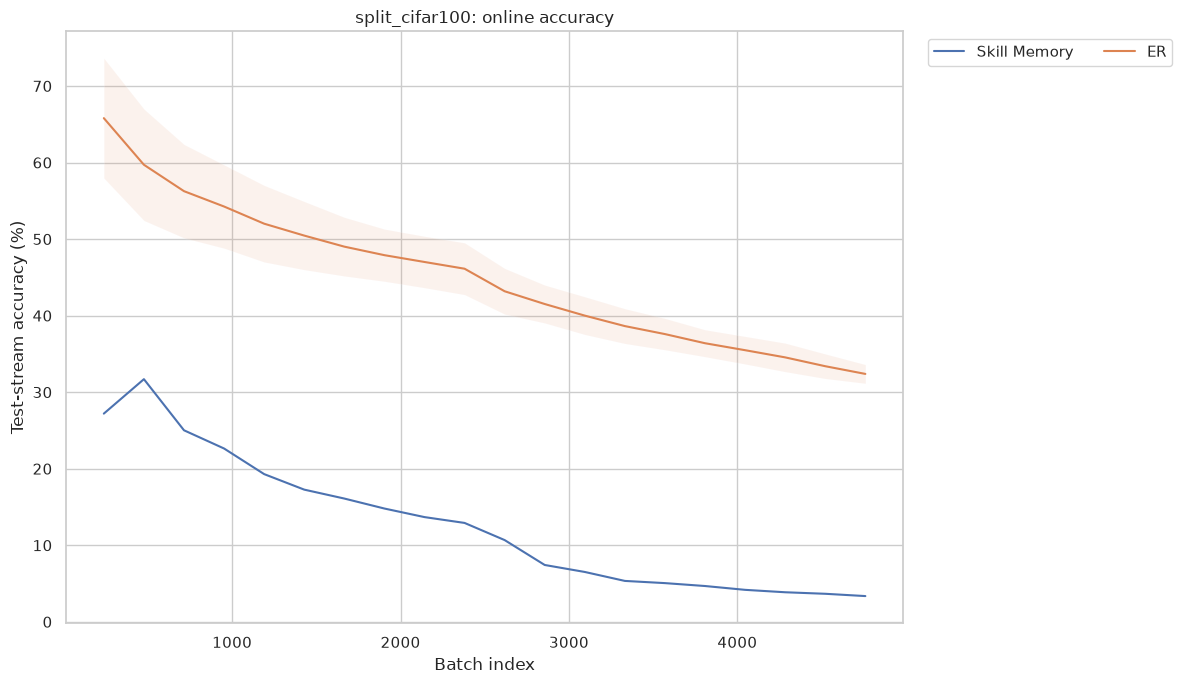

In [4]:
window = 10
fig, ax = plt.subplots(figsize=(12, 7))

for label, result in frames.items():
    df = result.get("training")
    if df is None or TEST_STREAM not in df.columns:
        continue
    x = df[["seed", "mb_index", TEST_STREAM]].dropna().sort_values(["seed", "mb_index"]).copy()
    x["smooth"] = x.groupby("seed")[TEST_STREAM].transform(lambda s: s.rolling(window, min_periods=1).mean())
    g = x.groupby("mb_index")["smooth"].agg(["mean", "std"]).reset_index()
    ax.plot(g["mb_index"], 100 * g["mean"], label=label)
    ax.fill_between(g["mb_index"], 100 * (g["mean"] - g["std"]), 100 * (g["mean"] + g["std"]), alpha=0.10)

ax.set(xlabel="Batch index", ylabel="Test-stream accuracy (%)", title=f"{BENCHMARK}: online accuracy")
ax.legend(ncol=2, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


## 4. Catastrophic forgetting over training

This is the evolution of **average forgetting** across the 20 tasks as training progresses. It uses the same `compute_average_forgetting` utility used by the scalar comparison metric above. Lower is better: increasing values mean previously learned task accuracy is being lost.

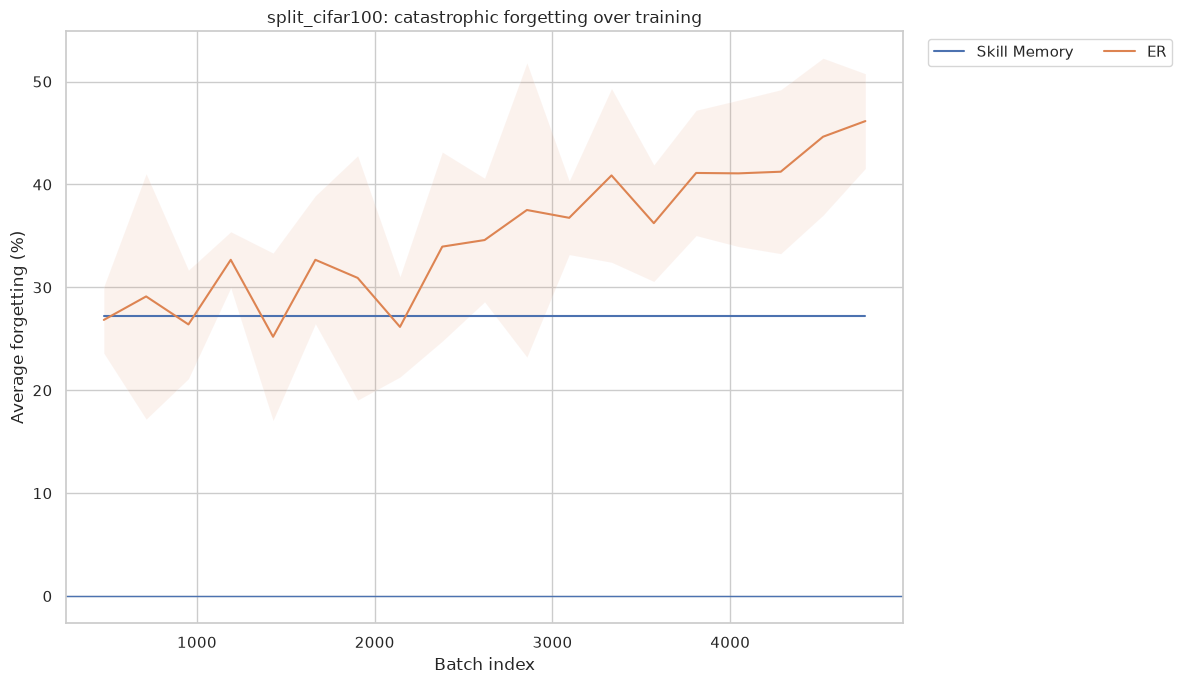

In [5]:
fig, ax = plt.subplots(figsize=(12, 7))

for label, result in frames.items():
    df = result.get("training")
    if df is None or df.empty:
        continue

    required = [f"{TEST_EXP}{i:03d}" for i in range(NUM_TASKS)]
    if not set(required).issubset(df.columns):
        warnings.warn(f"Skipping forgetting curve for {label}: missing task accuracy columns")
        continue

    forgetting_df = compute_average_forgetting(df.copy(), NUM_TASKS)
    x = forgetting_df[["seed", "mb_index", "Average_Forgetting"]].dropna()
    if x.empty:
        continue

    g = x.groupby("mb_index")["Average_Forgetting"].agg(["mean", "std"]).reset_index()
    ax.plot(g["mb_index"], 100 * g["mean"], label=label)
    ax.fill_between(g["mb_index"], 100 * (g["mean"] - g["std"]), 100 * (g["mean"] + g["std"]), alpha=0.10)

ax.axhline(0, linewidth=1)
ax.set(xlabel="Batch index", ylabel="Average forgetting (%)", title=f"{BENCHMARK}: catastrophic forgetting over training")
ax.legend(ncol=2, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


## 5. Reproducibility

The notebook reads committed/reference results when they are present, but the plots do not depend on hidden local paths. For a fresh Colab run, clone the repository, install `requirements.txt`, obtain CIFAR-100 under the configured data root, run the desired strategies with the same benchmark configuration and seeds, and rerun this notebook. The result directories must follow the same naming convention used above.

In [6]:
analysis_dir = RESULTS_ROOT / "analysis"
analysis_dir.mkdir(parents=True, exist_ok=True)
summary_path = analysis_dir / "skill_memory_strategy_comparison.csv"
summary_df.to_csv(summary_path, index=False)
print(f"Wrote {summary_path}")


Wrote /home/kobros-tech/workspace/AI/ocl_survey/results/analysis/skill_memory_strategy_comparison.csv
